# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

plt.rcParams['figure.figsize'] = (10, 6)

## 1. Preprocessing

1. Read the file [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Create a dataframe `df` with the columns: `uid`, `labname`, `numTrials`, `hour`, `dayofweek` where `hour` is extracted from the `timestamp` as well as the `dayofweek` (`0` is Monday, `6` is Sunday). We will try to predict the day of the week having data about which user made a commit for which lab at which hour and which try it was.
3. Using `OneHotEncoder()` transform your categorical features, delete from the dataframe the initial columns.
4. Use `StandardScaler()` and scale your continuous features.
5. Save the dataframe as `dayofweek.csv`.
6. Before trying out different algorithms, find out the accuracy of the naive algorithms – the one that predicts everything as the most popular class.

In [ ]:

df_raw = pd.read_csv('data/checker_submits.csv')

df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw['hour'] = df_raw['timestamp'].dt.hour
df_raw['dayofweek'] = df_raw['timestamp'].dt.dayofweek

df = df_raw[['uid', 'labname', 'numTrials', 'hour', 'dayofweek']].copy()

categorical_cols = ['uid', 'labname']
continuous_cols = ['numTrials', 'hour']

encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(df[categorical_cols])

encoded_columns = encoder.get_feature_names_out(categorical_cols)

df_encoded = pd.DataFrame(encoded_data, columns=encoded_columns, index=df.index)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[continuous_cols])
df_scaled = pd.DataFrame(scaled_data, columns=continuous_cols, index=df.index)

X = pd.concat([df_scaled, df_encoded], axis=1)
y = df['dayofweek']

df_final = pd.concat([X, y], axis=1)
df_final.to_csv('data/dayofweek.csv', index=False)

most_popular_day = y.value_counts().idxmax()
naive_preds = [most_popular_day] * len(y)
naive_accuracy = accuracy_score(y, naive_preds)

print(f"Самый популярный день недели: {most_popular_day}")
print(f"Accuracy наивного прогноза: {naive_accuracy:.5f}")
print(f"\nРазмер итоговой таблицы признаков X: {X.shape}")

Самый популярный день недели: 3
Accuracy наивного прогноза: 0.23487544483985764

Размер итоговой таблицы признаков X: (1686, 43)


## 2. Algorithms

### a. Logreg

1. Train logistic regression, for the baseline model use `random_state=21`, `fit_intercept=False`. 
2. Calculate the accuracy.
3. Write a function that draws the plot (`barh`) taking coefficients of any trained models, names of the features and the number of `top-n` most important features to display.
4. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model.
5. Remember that it is a multiclass classification and `coef_` returns a matrix, to calculate importance for a feature you need to sum all the individual feature importances for all the target values.

Accuracy Логистической регрессии (OvR): 0.6209964412811388


/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: Runtime

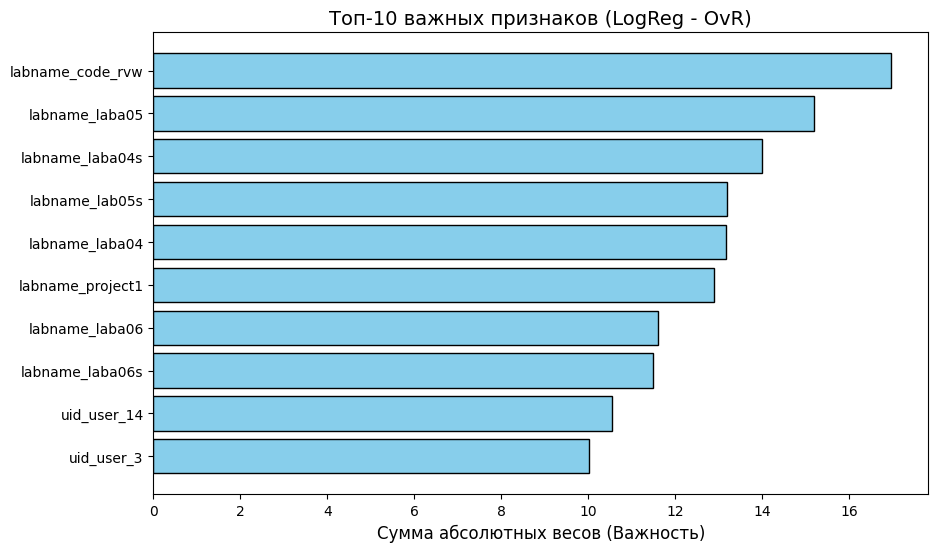

In [22]:
logreg = LogisticRegression(random_state=21, fit_intercept=False, multi_class='ovr')
logreg.fit(X, y)

y_pred_logreg = logreg.predict(X)
acc_logreg = accuracy_score(y, y_pred_logreg)
print(f"Accuracy Логистической регрессии (OvR): {acc_logreg}")

def plot_feature_importances(coefs, feature_names, top_n=10, title="Feature Importances"):
    importance = np.sum(np.abs(coefs), axis=0)
    
    imp_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    })
    
    top_features = imp_df.sort_values(by='importance', ascending=False).head(top_n)
    top_features = top_features.sort_values(by='importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(top_features['feature'], top_features['importance'], color='skyblue', edgecolor='black')
    plt.title(title, fontsize=14)
    plt.xlabel('Сумма абсолютных весов (Важность)', fontsize=12)
    plt.show()

plot_feature_importances(logreg.coef_, X.columns, top_n=10, title="Топ-10 важных признаков (LogReg - OvR)")

### b. SVC

1. Train a `SVC` model, for the baseline model use parameters `kernel='linear'`, `probability=True`, `random_state=21`. 
2. Try different kernels, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model for the linear kernel *

*By default SVC uses “one vs one” strategy of the classification, thus in `coef_` it returns a matrix. To calculate importance for a feature you need to use [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) over the SVC and sum all the individual feature importances for all the target values.

Accuracy SVC (linear, baseline): 0.61269


/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


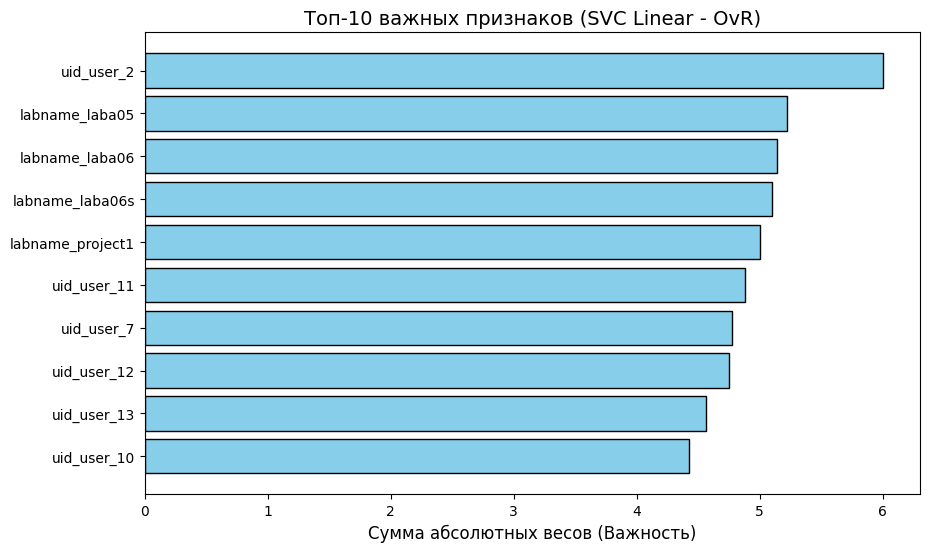


Пробуем разные ядра для SVC:
Ядро 'linear': accuracy = 0.70285
Ядро 'poly': accuracy = 0.85943
Ядро 'rbf': accuracy = 0.85587
Ядро 'sigmoid': accuracy = 0.39976


In [23]:


svc_baseline = SVC(kernel='linear', probability=True, random_state=21)

ovr_svc = OneVsRestClassifier(svc_baseline)
ovr_svc.fit(X, y)

y_pred_svc = ovr_svc.predict(X)
print(f"Accuracy SVC (linear, baseline): {accuracy_score(y, y_pred_svc):.5f}")

# Собираем coef_ из всех OvR-моделей
coefs = np.vstack([est.coef_.ravel() for est in ovr_svc.estimators_])

plot_feature_importances(
    coefs,
    X.columns,
    top_n=10,
    title="Топ-10 важных признаков (SVC Linear - OvR)"
)

print("\nПробуем разные ядра для SVC:")
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

for kernel in kernels:
    model = SVC(kernel=kernel, probability=True, random_state=21)
    model.fit(X, y)
    acc = accuracy_score(y, model.predict(X))
    print(f"Ядро '{kernel}': accuracy = {acc:.5f}")

### c. Decision tree

1. Train a `DecisionTreeClassifier` using for the baseline model `max_depth=4`, `random_state=21`. 
2. Try different values of `max_depth`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

Accuracy Decision Tree (baseline, max_depth=4): 0.55160


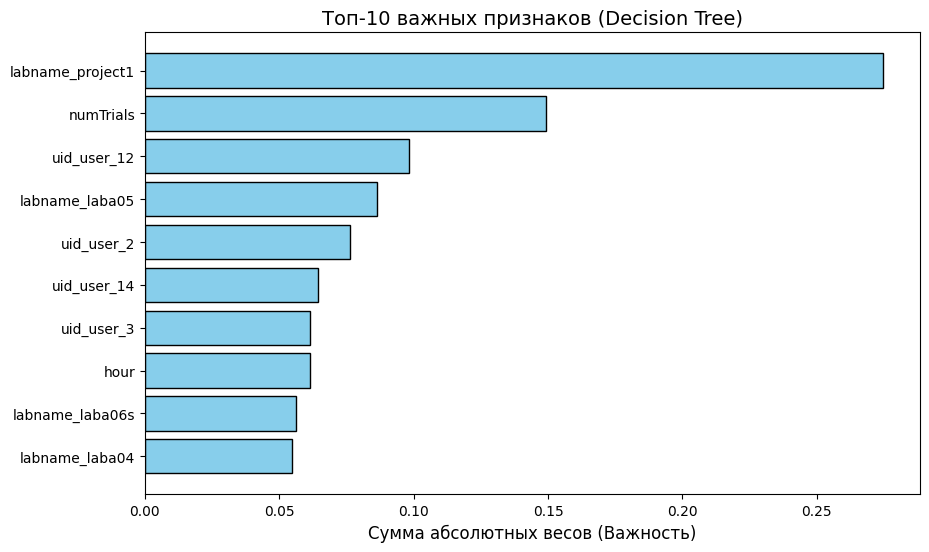


Пробуем разную глубину для Decision Tree:
max_depth=1: accuracy = 0.35765
max_depth=2: accuracy = 0.43891
max_depth=3: accuracy = 0.48992
max_depth=4: accuracy = 0.55160
max_depth=5: accuracy = 0.61091
max_depth=6: accuracy = 0.66370
max_depth=7: accuracy = 0.70641
max_depth=8: accuracy = 0.75030
max_depth=9: accuracy = 0.78470
max_depth=10: accuracy = 0.81969
max_depth=11: accuracy = 0.84994
max_depth=12: accuracy = 0.88316
max_depth=13: accuracy = 0.91044
max_depth=14: accuracy = 0.93179


In [24]:
dtc = DecisionTreeClassifier(max_depth=4, random_state=21)
dtc.fit(X, y)

y_pred_dtc = dtc.predict(X)
acc_dtc = accuracy_score(y, y_pred_dtc)
print(f"Accuracy Decision Tree (baseline, max_depth=4): {acc_dtc:.5f}")

plot_feature_importances([dtc.feature_importances_], X.columns, top_n=10, title="Топ-10 важных признаков (Decision Tree)")

print("\nПробуем разную глубину для Decision Tree:")
for depth in range(1, 15): 
    model = DecisionTreeClassifier(max_depth=depth, random_state=21)
    model.fit(X, y)
    acc = accuracy_score(y, model.predict(X))
    print(f"max_depth={depth}: accuracy = {acc:.5f}")

### d. Random forest

In real life forest is a set of trees. The same thing is with machine learning. Random forest is a set of individual decision trees (check the documentation for more details).

1. Train a `RandomForestClassifier` using for the baseline model parameters `n_estimators=100`, `max_depth = 25`, `random_state=21`. 
2. Try different values of `max_depth` and `n_estimators`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

Accuracy Random Forest (baseline): 1.00000


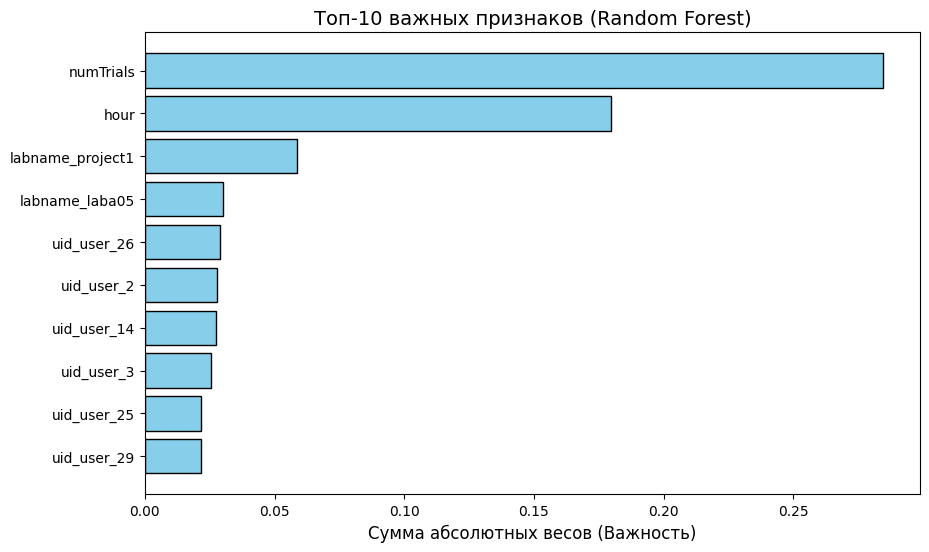


Пробуем разные параметры для Random Forest:
n_estimators=10, max_depth=5: accuracy = 0.60320
n_estimators=10, max_depth=15: accuracy = 0.96441
n_estimators=10, max_depth=25: accuracy = 0.99585
n_estimators=50, max_depth=5: accuracy = 0.58482
n_estimators=50, max_depth=15: accuracy = 0.97865
n_estimators=50, max_depth=25: accuracy = 1.00000
n_estimators=100, max_depth=5: accuracy = 0.57948
n_estimators=100, max_depth=15: accuracy = 0.97805
n_estimators=100, max_depth=25: accuracy = 1.00000


In [25]:
rf_baseline = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
rf_baseline.fit(X, y)

y_pred_rf = rf_baseline.predict(X)
acc_rf = accuracy_score(y, y_pred_rf)
print(f"Accuracy Random Forest (baseline): {acc_rf:.5f}")

plot_feature_importances([rf_baseline.feature_importances_], X.columns, top_n=10, title="Топ-10 важных признаков (Random Forest)")

print("\nПробуем разные параметры для Random Forest:")
estimators_list = [10, 50, 100]
depths_list = [5, 15, 25]

for n in estimators_list:
    for d in depths_list:
        model = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=21)
        model.fit(X, y)
        acc = accuracy_score(y, model.predict(X))
        print(f"n_estimators={n}, max_depth={d}: accuracy = {acc:.5f}")